# Character-Level LSTM Generative Text Pipeline

Recurrent Neural Networks (RNNs) and LSTMs excel at modeling character sequence dependencies. Character-level language models learn probability coordinates of the next character given a history sequence of characters. This notebook implements a character-level LSTM in PyTorch, trains it on a synthetic Shakespeare-like text, and visualizes cross-entropy training loss decay.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Generate a synthetic Shakespeare-like text corpus
text_corpus = (
    "to be or not to be that is the question "
    "whether tis nobler in the mind to suffer "
    "the slings and arrows of outrageous fortune "
    "or to take arms against a sea of troubles "
    "and by opposing end them to die to sleep "
)

# Extract vocabulary (distinct characters)
chars = sorted(list(set(text_corpus)))
vocab_size = len(chars)
char_to_idx = {char: idx for idx, char in enumerate(chars)}
idx_to_char = {idx: char for idx, char in enumerate(chars)}

print("Corpus Length:", len(text_corpus))
print("Vocabulary Size:", vocab_size)
print("Char mapping:", char_to_idx)



Corpus Length: 208
Vocabulary Size: 22
Char mapping: {' ': 0, 'a': 1, 'b': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'k': 9, 'l': 10, 'm': 11, 'n': 12, 'o': 13, 'p': 14, 'q': 15, 'r': 16, 's': 17, 't': 18, 'u': 19, 'w': 20, 'y': 21}


## Sequence Processing and Formatting

We transform our text into sequential training slices: taking 15 character sequence inputs to predict the immediately following 1 character output.



In [2]:
seq_len = 15
X_data, y_data = [], []

for i in range(len(text_corpus) - seq_len):
    input_seq = text_corpus[i : i + seq_len]
    target_char = text_corpus[i + seq_len]
    
    # Convert characters to indices
    X_data.append([char_to_idx[c] for c in input_seq])
    y_data.append(char_to_idx[target_char])

# Convert to tensors
X_tensor = torch.LongTensor(X_data) # [n_samples, seq_len]
y_tensor = torch.LongTensor(y_data) # [n_samples]

print("Processed training pairs count:", len(X_tensor))



Processed training pairs count: 193


## Character Generator Network Architecture

We implement the character generator network in PyTorch:
1. **Embedding Layer**: Projects integer character index values onto continuous vectors space.
2. **LSTM Layer**: Processes sequential vectors, tracking temporal dependencies.
3. **Linear Decoder Head**: Maps hidden vectors to probability scores across the vocabulary.



In [3]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=16, hidden_dim=64):
        super(CharLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # Set batch_first=True
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        # Use only the final sequence step output for prediction
        final_output = lstm_out[:, -1, :]
        out = self.fc(final_output)
        return out

model = CharLSTM(vocab_size=vocab_size, embedding_dim=16, hidden_dim=64)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)



## Language Model Training Loop

We train the generative language model for 60 epochs, recording cross-entropy loss decay values.



In [4]:
epochs = 60
losses = []

for epoch in range(1, epochs + 1):
    model.train()
    predictions = model(X_tensor)
    loss = criterion(predictions, y_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if epoch % 15 == 0:
        print(f"Epoch {epoch:2d}/{epochs} | Cross-Entropy Training Loss: {loss.item():.4f}")



Epoch 15/60 | Cross-Entropy Training Loss: 2.0835
Epoch 30/60 | Cross-Entropy Training Loss: 1.0068
Epoch 45/60 | Cross-Entropy Training Loss: 0.2531
Epoch 60/60 | Cross-Entropy Training Loss: 0.0428


## Loss Convergence Plot

We plot the cross-entropy training loss decay across epochs using Matplotlib to monitor model convergence.



<cell>:9: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



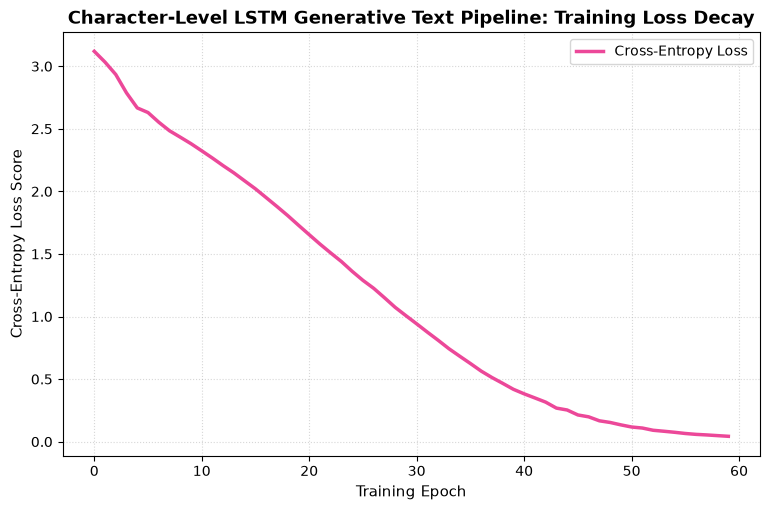

In [5]:
plt.figure(figsize=(9, 5.5))
plt.plot(losses, color='#EC4899', linewidth=2.5, label='Cross-Entropy Loss')

plt.title('Character-Level LSTM Generative Text Pipeline: Training Loss Decay', fontsize=13, fontweight='bold')
plt.xlabel('Training Epoch', fontsize=11)
plt.ylabel('Cross-Entropy Loss Score', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()
